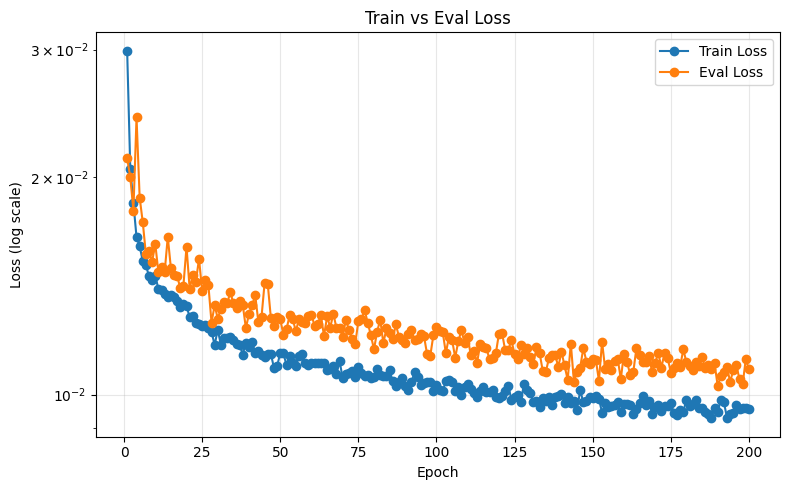

In [60]:
import json
import matplotlib.pyplot as plt

with open("training_log_recurrent_confidence_closed_rooms_C24.json") as f:
    data = json.load(f)

#data = data[10:]
epochs = [d["epoch"] for d in data]
train_losses = [d["train_loss"] for d in data]
eval_losses = [d["eval_loss"] for d in data]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_losses, marker="o", label="Train Loss")
ax.plot(epochs, eval_losses, marker="o", label="Eval Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Train vs Eval Loss")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

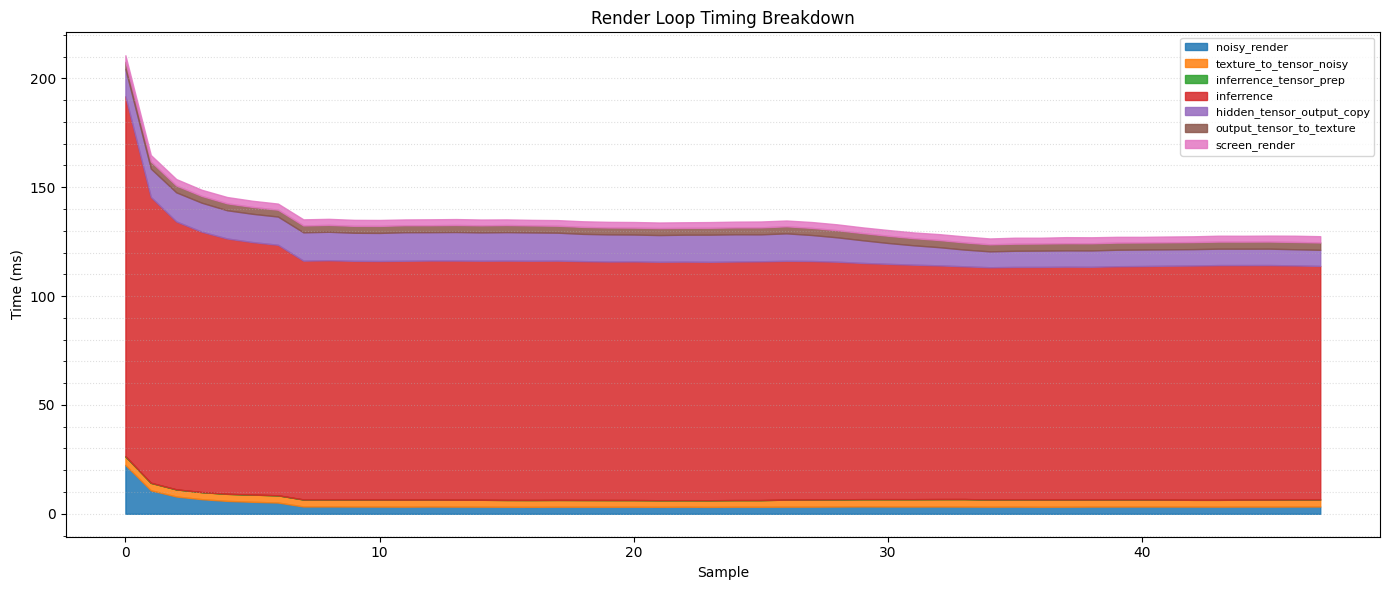

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

df = pd.read_csv('perf.csv')

section_cols = [c for c in df.columns if c not in ('fps', 'frame_time')]

for col in section_cols:
    df[col] = df[col].str.replace('ms', '').astype(float)

fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(df))
bottom = np.zeros(len(df))

colors = plt.cm.tab10.colors
for i, col in enumerate(section_cols):
    ax.fill_between(x, bottom, bottom + df[col].values,
                    label=col, alpha=0.85, color=colors[i % len(colors)])
    bottom += df[col].values

ax.set_xlabel('Sample')
ax.set_ylabel('Time (ms)')
ax.set_title('Render Loop Timing Breakdown')
ax.legend(loc='upper right', fontsize=8)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis='y', which='both', linestyle=':', alpha=0.4)

plt.tight_layout()
plt.show()

In [62]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt


CSV_PATHS = [
    "eval_metrics_kitchen/evaluation_metrics_unet_garden.csv",
    "eval_metrics_kitchen/evaluation_metrics_recurrent_no_conf_garden.csv",
    "eval_metrics_kitchen/evaluation_metrics_recurrent_no_conf_train_closed_rooms_eval_kitchen.csv",

    "eval_metrics_kitchen/evaluation_metrics_recurrent_conf_garden.csv",
    "eval_metrics_kitchen/evaluation_metrics_recurrent_conf_closed_rooms.csv",
    

    "eval_metrics_garden/evaluation_metrics_recurrent_no_conf_train_garden_eval_garden.csv",
    "eval_metrics_garden/evaluation_metrics_recurrent_no_conf_train_closed_rooms_eval_garden.csv",
    "eval_metrics_garden/evaluation_metrics_recurrent_conf_train_garden_eval_garden.csv",
    "eval_metrics_garden/evaluation_metrics_recurrent_conf_train_closed_rooms_eval_garden.csv",
]


CSV_NAME_MAP = {
    "evaluation_metrics_unet_garden": {
        "model": "U-Net",
        "dataset": "Garden",
        "eval_set": "Kitchen",
    },
    
    "evaluation_metrics_recurrent_no_conf_garden": {
        "model": "Recurrent",
        "dataset": "Garden",
        "eval_set": "Kitchen",
    },
    "evaluation_metrics_recurrent_no_conf_train_closed_rooms_eval_kitchen": {
        "model": "Recurrent",
        "dataset": "Garden + Gym + Office",
        "eval_set": "Kitchen",
    },
    
    "evaluation_metrics_recurrent_conf_garden": {
        "model": "Recurrent + Conf.",
        "dataset": "Garden",
        "eval_set": "Kitchen",
    },
    "evaluation_metrics_recurrent_conf_closed_rooms": {
        "model": "Recurrent + Conf.",
        "dataset": "Garden + Gym + Office",
        "eval_set": "Kitchen",
    },
    
    

    "evaluation_metrics_recurrent_no_conf_train_garden_eval_garden": {
        "model": "Recurrent",
        "dataset": "Garden",
        "eval_set": "Garden",
    },
    "evaluation_metrics_recurrent_no_conf_train_closed_rooms_eval_garden": {
        "model": "Recurrent",
        "dataset": "Garden + Gym + Office",
        "eval_set": "Garden",
    },
    
    "evaluation_metrics_recurrent_conf_train_garden_eval_garden": {
        "model": "Recurrent + Conf.",
        "dataset": "Garden",
        "eval_set": "Garden",
    },
    "evaluation_metrics_recurrent_conf_train_closed_rooms_eval_garden": {
        "model": "Recurrent + Conf.",
        "dataset": "Garden + Gym + Office",
        "eval_set": "Garden",
    },
}


def infer_names_from_csv_path(csv_path: str) -> tuple[str, str, str]:
    csv_stem = Path(csv_path).stem

    if csv_stem in CSV_NAME_MAP:
        return (
            CSV_NAME_MAP[csv_stem]["model"],
            CSV_NAME_MAP[csv_stem]["dataset"],
            CSV_NAME_MAP[csv_stem]["eval_set"],
        )

    return csv_stem, csv_stem, csv_stem


def load_metrics_table(csv_paths):
    rows = []

    metric_cols = [
        "mean_l1",
        "mean_gradient_l1",
        "mean_temporal_delta_l1",
        "mean_sliding_seq7_loss",
    ]

    for csv_path in csv_paths:
        df = pd.read_csv(csv_path)

        model_name, dataset_name, eval_set_name = infer_names_from_csv_path(csv_path)

        for _, row in df.iterrows():
            output_row = {
                "Model": model_name,
                "Training Dataset": dataset_name,
                "Evaluation Dataset": eval_set_name,
            }

            for col in metric_cols:
                if col in df.columns:
                    output_row[col] = row[col]

            rows.append(output_row)

    return pd.DataFrame(rows)


table_df = load_metrics_table(CSV_PATHS)

table_df = table_df.rename(columns={
    "mean_l1": "L1",
    "mean_gradient_l1": "Gradient L1",
    "mean_temporal_delta_l1": "Temporal Delta L1",
    "mean_sliding_seq7_loss": "Sequence Loss",
})

numeric_cols = table_df.select_dtypes(include="number").columns
table_df[numeric_cols] = table_df[numeric_cols].round(6)


latex_table = table_df.to_latex(
    index=False,
    escape=False,
    float_format="%.6f",
    caption="Evaluation metrics for different models, training datasets, and evaluation datasets.",
    label="tab:evaluation_metric_results",
)

print(latex_table)

output_path = "evaluation_metrics_table.tex"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(latex_table)

print(f"Saved LaTeX table to: {output_path}")

\begin{table}
\caption{Evaluation metrics for different models, training datasets, and evaluation datasets.}
\label{tab:evaluation_metric_results}
\begin{tabular}{lllrrrr}
\toprule
Model & Training Dataset & Evaluation Dataset & L1 & Gradient L1 & Temporal Delta L1 & Sequence Loss \\
\midrule
U-Net & Garden & Kitchen & 0.025545 & 0.007484 & 0.019091 & 0.023086 \\
Recurrent & Garden & Kitchen & 0.019515 & 0.007129 & 0.016840 & 0.007847 \\
Recurrent & Garden + Gym + Office & Kitchen & 0.015617 & 0.006846 & 0.015240 & 0.006506 \\
Recurrent + Conf. & Garden & Kitchen & 0.022702 & 0.007493 & 0.018135 & 0.008957 \\
Recurrent + Conf. & Garden + Gym + Office & Kitchen & 0.057187 & 0.007532 & 0.018647 & 0.019361 \\
Recurrent & Garden & Garden & 0.038258 & 0.020736 & 0.037074 & 0.016051 \\
Recurrent & Garden + Gym + Office & Garden & 0.038384 & 0.021109 & 0.037344 & 0.016124 \\
Recurrent + Conf. & Garden & Garden & 0.040013 & 0.021395 & 0.038408 & 0.016746 \\
Recurrent + Conf. & Garden + Gym + O

In [63]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

LABEL_COL_WIDTH = 90
CELL_PADDING = 8
HEADER_HEIGHT = 36
ROW_PADDING = 8
BACKGROUND = (255, 255, 255)
TEXT_COLOR = (0, 0, 0)

def frame_name(frame_idx: int, kind: str) -> str:
    return f"frame_{frame_idx:04d}_{kind}.png"


def crop_image(img: Image.Image, x: int, y: int, w: int, h: int) -> Image.Image:
    return img.crop((x, y, x + w, y + h))


def load_and_crop(path: Path, crop_box: tuple[int, int, int, int]) -> Image.Image:
    x, y, w, h = crop_box

    if not path.exists():
        raise FileNotFoundError(f"Missing image: {path}")

    img = Image.open(path).convert("RGB")
    return crop_image(img, x, y, w, h)


def get_available_frame_indices(reference_dir: Path) -> list[int]:
    frame_indices = []

    for path in sorted(reference_dir.glob("frame_*_input.png")):
        parts = path.stem.split("_")

        if len(parts) != 3:
            continue

        try:
            frame_indices.append(int(parts[1]))
        except ValueError:
            continue

    return sorted(frame_indices)


def get_font(size: int = 18):
    candidates = [
        "DejaVuSans.ttf",
        "/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf",
        "/System/Library/Fonts/Supplemental/Arial.ttf",
        "arial.ttf",
    ]

    for candidate in candidates:
        try:
            return ImageFont.truetype(candidate, size)
        except OSError:
            pass

    return ImageFont.load_default()


def draw_centered_text(
    draw: ImageDraw.ImageDraw,
    text: str,
    box: tuple[int, int, int, int],
    font,
    fill=(0, 0, 0),
):
    x0, y0, x1, y1 = box

    bbox = draw.textbbox((0, 0), text, font=font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    x = x0 + (x1 - x0 - text_w) // 2
    y = y0 + (y1 - y0 - text_h) // 2

    draw.text((x, y), text, font=font, fill=fill)


def select_frame_indices(
    available_frame_indices: list[int],
    start_frame: int,
    num_frames: int | None,
) -> list[int]:
    frame_indices = [
        idx for idx in available_frame_indices
        if idx >= start_frame
    ]

    if num_frames is not None:
        frame_indices = frame_indices[:num_frames]

    if not frame_indices:
        raise ValueError(
            f"No frames available from START_FRAME={start_frame}. "
            f"Available range: {available_frame_indices[0]}–{available_frame_indices[-1]}"
        )

    return frame_indices


def build_comparison_grid(
    model_output_dirs: list[Path],
    model_names: list[str],
    crop_box: tuple[int, int, int, int],
    output_path: Path,
    start_frame: int = 0,
    num_frames: int | None = None,
):
    if len(model_output_dirs) == 0:
        raise ValueError("model_output_dirs must contain at least one folder.")

    if len(model_output_dirs) != len(model_names):
        raise ValueError(
            f"Expected same number of model folders and model names, got "
            f"{len(model_output_dirs)} folders and {len(model_names)} names."
        )

    reference_dir = model_output_dirs[0]

    available_frame_indices = get_available_frame_indices(reference_dir)

    if not available_frame_indices:
        raise ValueError(f"No frame_*_input.png files found in: {reference_dir}")

    frame_indices = select_frame_indices(
        available_frame_indices=available_frame_indices,
        start_frame=start_frame,
        num_frames=num_frames,
    )

    crop_x, crop_y, crop_w, crop_h = crop_box

    image_column_names = ["Input"] + model_names + ["Target"]

    num_rows = len(frame_indices)
    num_image_cols = len(image_column_names)

    cell_w = crop_w
    cell_h = crop_h

    grid_w = (
        LABEL_COL_WIDTH
        + num_image_cols * cell_w
        + (num_image_cols + 2) * CELL_PADDING
    )

    grid_h = (
        HEADER_HEIGHT
        + num_rows * cell_h
        + (num_rows + 1) * ROW_PADDING
    )

    canvas = Image.new("RGB", (grid_w, grid_h), BACKGROUND)
    draw = ImageDraw.Draw(canvas)

    header_font = get_font(18)
    label_font = get_font(18)

    # Empty top-left header cell
    draw_centered_text(
        draw,
        "Frame",
        (CELL_PADDING, 0, CELL_PADDING + LABEL_COL_WIDTH, HEADER_HEIGHT),
        font=header_font,
        fill=TEXT_COLOR,
    )

    # Image column headers
    image_grid_x0 = CELL_PADDING + LABEL_COL_WIDTH + CELL_PADDING

    for col_idx, col_name in enumerate(image_column_names):
        x0 = image_grid_x0 + col_idx * (cell_w + CELL_PADDING)
        x1 = x0 + cell_w

        draw_centered_text(
            draw,
            col_name,
            (x0, 0, x1, HEADER_HEIGHT),
            font=header_font,
            fill=TEXT_COLOR,
        )

    for row_idx, source_frame_idx in enumerate(frame_indices):
        display_frame_idx = row_idx

        y0 = HEADER_HEIGHT + ROW_PADDING + row_idx * (cell_h + ROW_PADDING)

        # Left-side sequential frame label
        label_x0 = CELL_PADDING
        label_x1 = CELL_PADDING + LABEL_COL_WIDTH

        draw_centered_text(
            draw,
            f"Frame {display_frame_idx}",
            (label_x0, y0, label_x1, y0 + cell_h),
            font=label_font,
            fill=TEXT_COLOR,
        )

        row_images = []

        # Input from first model folder
        input_path = reference_dir / frame_name(source_frame_idx, "input")
        row_images.append(load_and_crop(input_path, crop_box))

        # Output from each model folder
        for model_dir in model_output_dirs:
            output_path_img = model_dir / frame_name(source_frame_idx, "output")
            row_images.append(load_and_crop(output_path_img, crop_box))

        # Target from first model folder
        target_path = reference_dir / frame_name(source_frame_idx, "target")
        row_images.append(load_and_crop(target_path, crop_box))

        for col_idx, img in enumerate(row_images):
            x0 = image_grid_x0 + col_idx * (cell_w + CELL_PADDING)
            canvas.paste(img, (x0, y0))

    output_path.parent.mkdir(parents=True, exist_ok=True)
    canvas.save(output_path)

    print(f"Saved comparison grid to: {output_path}")
    print(f"Source frames included: {frame_indices}")
    print(f"Displayed labels: Frame 0–Frame {len(frame_indices) - 1}")
    print(f"Crop: x={crop_x}, y={crop_y}, w={crop_w}, h={crop_h}")



In [64]:

MODEL_OUTPUT_DIRS = [
    Path("visualizaton_frames/unet_train_garden_eval_kitchen"),
    Path("visualizaton_frames/rec_no_conf_train_garden_eval_kitchen"),
    Path("visualizaton_frames/rec_conf_train_garden_eval_kitchen"),
]

MODEL_NAMES = [
    "U-Net",
    "Recurrent no confidence",
    "Recurrent with confidence",
]

OUTPUT_PATH = Path("comparison_grid.png")

CROP_X = 300
CROP_Y = 200
CROP_W = 256
CROP_H = 256

START_FRAME = 5
NUM_FRAMES = 5


build_comparison_grid(
    model_output_dirs=MODEL_OUTPUT_DIRS,
    model_names=MODEL_NAMES,
    crop_box=(CROP_X, CROP_Y, CROP_W, CROP_H),
    output_path=OUTPUT_PATH,
    start_frame=START_FRAME,
    num_frames=NUM_FRAMES,
)

Saved comparison grid to: comparison_grid.png
Source frames included: [5, 6, 7, 8, 9]
Displayed labels: Frame 0–Frame 4
Crop: x=300, y=200, w=256, h=256
